# 03 · Historical fraud-risk monitoring prototype

This notebook reuses the **saved predictions of the original frozen policy** from Notebook 02. It does not fit a model,
change the decision threshold or claim that the previously inspected historical-test period is new evaluation data.
The balance-dependent policy remains subject to the source-provenance limitation documented in Notebook 02.

**Decision support:** identify changes that an analyst should investigate, while separating operational behaviour from
performance that can only be assessed when fraud labels mature. Monitoring flags request investigation; they are not
proof of fraud, statistical hypothesis tests, or instructions to block payments.

| Metric | When it can be calculated |
|---|---|
| Volume, type mix and requested-amount distribution | On receipt of the transaction instruction. |
| Recorded opening-balance distribution and model scores | At scoring, conditional on a verified balance snapshot; this dataset's provenance remains uncertain. |
| Alert volume/rate and score distribution | Immediately after scoring, without fraud labels. |
| Fraud prevalence, precision, recall, false positives and missed fraud | After outcomes are confirmed. This replay uses retrospectively supplied labels. |

There are no confirmation timestamps, so we cannot reconstruct label maturity or true contemporaneous performance.
Do not treat the fraud labels displayed below as information the original decision-maker would already have known.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from fraud_utils import (ROOT, ARTIFACTS, prepare_outputs, file_sha256, metrics, period_summary,
                         distribution_bins, population_stability, save_table, save_figure)

prepare_outputs()
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.figsize': (11, 4.5), 'axes.grid': True, 'grid.alpha': 0.2})
policy_path = ROOT / 'config' / 'frozen_policy.json'
frozen = json.loads(policy_path.read_text())
manifest = json.loads((ROOT / 'reports' / 'prediction_manifest.json').read_text())
prediction_path = ARTIFACTS / 'frozen_predictions.csv.gz'
assert file_sha256(policy_path) == manifest['policy_sha256']
assert file_sha256(prediction_path) == manifest['predictions_sha256']
assert frozen['data_sha256'] == manifest['data_sha256']
assert file_sha256(ROOT / 'fraud_utils.py') == manifest['shared_code_sha256']
replay = pd.read_csv(prediction_path, float_precision='round_trip', dtype={'type': 'category'})
threshold = frozen['threshold']
assert len(replay) == manifest['rows'] and replay.row_id.is_unique
assert np.array_equal(replay.alert.to_numpy(), replay.score.ge(threshold).to_numpy())
reference = replay.loc[replay.period.eq('Development reference')].copy()
current = replay.loc[replay.period.eq('Historical replay')].copy()
assert reference.step.between(324, 377).all() and current.step.between(378, 743).all()
assert reference.row_id.isin(current.row_id).sum() == 0
reproduced_metrics = metrics(current.isFraud, current.score, threshold)
for name, count in manifest['historical_counts'].items():
    assert reproduced_metrics[name] == count
print(f'Reused {len(reference):,} development-reference and {len(current):,} historical predictions. No model was refitted.')

Reused 410,437 development-reference and 408,077 historical predictions. No model was refitted.


## Reference and monitoring rules

Use the original validation period (steps 324–377) as the development reference. It is out-of-training-sample but was used
for original model/threshold selection. The reference spans only 54 simulation hours; its bands are exploratory and may
be unstable or miss hourly seasonality.

- Per-step volume and alert-rate bands use the development reference's **1st and 99th percentiles**. These descriptive
  bands are not calibrated false-alarm limits. No historical-test values set the bands.
- Amount, opening-balance and score drift use **population stability index (PSI)** with development-quantile bins,
  open tails and a 0.5 count per-bin smoothing convention. A **0.20** watch level is an explicitly illustrative rule,
  not an industry requirement or statistically validated threshold. Suppress PSI when a period has fewer than 100 rows.
- A **10 percentage point** change in TRANSFER share is an illustrative type-mix rule. It also requires 100 rows.
- Periods with fewer than 100 transactions receive a low-volume flag, not a reliable performance or drift verdict.

The score threshold stays at the value in the frozen policy. Monitoring rules do not tune that decision threshold.
PSI is descriptive and sensitive to binning/sample size; a distribution change does not establish a performance change.

In [2]:
def per_step(frame):
    result = frame.groupby('step', observed=True).agg(
        transactions=('row_id', 'size'), alerts=('alert', 'sum')).reindex(
            range(int(frame.step.min()), int(frame.step.max()) + 1), fill_value=0)
    result['alert_rate'] = result.alerts / result.transactions.replace(0, np.nan)
    return result

reference_steps = per_step(reference)
current_steps = per_step(current)
bands = {name: {'low': float(reference_steps[name].quantile(0.01)),
                'high': float(reference_steps[name].quantile(0.99))}
         for name in ['transactions', 'alert_rate']}
MIN_PERIOD_ROWS = 100
PSI_WATCH = 0.20
TYPE_SHARE_CHANGE_WATCH = 0.10
bins = {feature: distribution_bins(reference[feature]) for feature in ['amount', 'oldbalanceOrg', 'score']}
reference_transfer_share = reference.type.eq('TRANSFER').mean()
monitoring_rules = {
    'reference_first_step': 324, 'reference_last_step': 377,
    'per_step_reference_quantiles': [0.01, 0.99], 'bands': bands,
    'illustrative_PSI_watch': PSI_WATCH, 'illustrative_type_share_change': TYPE_SHARE_CHANGE_WATCH,
    'minimum_period_rows': MIN_PERIOD_ROWS, 'fixed_score_threshold': threshold,
    'bin_edges': {name: [float(x) if np.isfinite(x) else ('-inf' if x < 0 else 'inf') for x in edges]
                  for name, edges in bins.items()},
}
(ROOT / 'reports' / 'monitoring_rules.json').write_text(json.dumps(monitoring_rules, indent=2) + '\n')
display(pd.DataFrame(bands).T.rename_axis('metric'))
for feature in bands:
    current_steps[f'{feature}_outside_reference'] = (
        current_steps[feature].lt(bands[feature]['low']) | current_steps[feature].gt(bands[feature]['high']))
current_steps['zero_volume'] = current_steps.transactions.eq(0)
save_table(current_steps.rename_axis('step').reset_index(), 'monitoring_per_step')

,low,high
metric,,
transactions,6.000000,19709.64
alert_rate,0.000173,1.00


## Time-based operational and confirmed-label diagnostics

Use calendar-free blocks of 24 simulation steps aligned to step 1. Boundary blocks can be partial; `steps_covered` and
sample counts make this explicit. Per-step volume bands are applied only to per-step data, not to these unequal blocks.
Rates divide by transactions in the specified block. Precision divides by alerts; recall divides by confirmed fraud.
NaN means a denominator is zero (or AP has only one class), not a measured zero. Label coverage is retrospective coverage.

In [3]:
periods = period_summary(current, threshold, step_width=24)
periods['retrospective_label_coverage'] = 1.0
periods['low_volume'] = periods.transactions.lt(MIN_PERIOD_ROWS)
drift_rows = []
for row in periods.itertuples():
    group = current.loc[current.step.between(row.first_step, row.last_step)]
    enough = len(group) >= MIN_PERIOD_ROWS
    drift_rows.append({
        'period': row.period,
        **{feature + '_PSI': population_stability(reference[feature], group[feature], bins[feature]) if enough else np.nan
           for feature in bins},
        'transfer_share_change': group.type.eq('TRANSFER').mean() - reference_transfer_share if enough else np.nan,
    })
periods = periods.merge(pd.DataFrame(drift_rows), on='period', validate='one_to_one')
psi_columns = [feature + '_PSI' for feature in bins]
periods['distribution_watch'] = periods[psi_columns].gt(PSI_WATCH).any(axis=1)
periods['type_mix_watch'] = periods.transfer_share_change.abs().gt(TYPE_SHARE_CHANGE_WATCH)
assert periods.transactions.sum() == len(current)
for name in ['TP', 'FP', 'FN', 'TN', 'alerts']:
    assert periods[name].sum() == reproduced_metrics[name]
save_table(periods, 'monitoring_periods')
display(periods[['first_step', 'last_step', 'steps_covered', 'transactions', 'alerts', 'alert_rate',
                 'fraud_count', 'fraud_prevalence', 'precision', 'recall', 'F1', 'AP', 'FP', 'FN',
                 'low_volume', 'distribution_watch', 'type_mix_watch']].round(5))

,first_step,last_step,steps_covered,transactions,alerts,alert_rate,fraud_count,fraud_prevalence,precision,recall,F1,AP,FP,FN,low_volume,distribution_watch,type_mix_watch
0,378,384,7,65710,66,0.00100,66,0.00100,1.0,1.00000,1.00000,1.0,0,0,False,False,False
1,385,408,24,187780,319,0.00170,320,0.00170,1.0,0.99688,0.99844,1.0,0,1,False,False,False
2,409,432,24,8068,266,0.03297,268,0.03322,1.0,0.99254,0.99625,1.0,0,2,False,False,False
3,433,456,24,4223,255,0.06038,256,0.06062,1.0,0.99609,0.99804,1.0,0,1,False,False,False
4,457,480,24,8142,236,0.02899,236,0.02899,1.0,1.00000,1.00000,1.0,0,0,False,False,False
5,481,504,24,10108,272,0.02691,272,0.02691,1.0,1.00000,1.00000,1.0,0,0,False,False,False
6,505,528,24,21529,256,0.01189,256,0.01189,1.0,1.00000,1.00000,1.0,0,0,False,False,False
7,529,552,24,20790,216,0.01039,216,0.01039,1.0,1.00000,1.00000,1.0,0,0,False,False,False
8,553,576,24,13774,279,0.02026,280,0.02033,1.0,0.99643,0.99821,1.0,0,1,False,False,False
9,577,600,24,24403,238,0.00975,240,0.00983,1.0,0.99167,0.99582,1.0,0,2,False,False,False


## Monitoring overview

The first four panels use transaction/scoring information. The lower-left panel requires confirmed fraud labels.
The lower-right drift measures need no labels, but the opening-balance and score inputs retain the policy's provenance
caveat. Amber shading or a watch line is a prompt to investigate, not an estimated financial loss or a fraud decision.

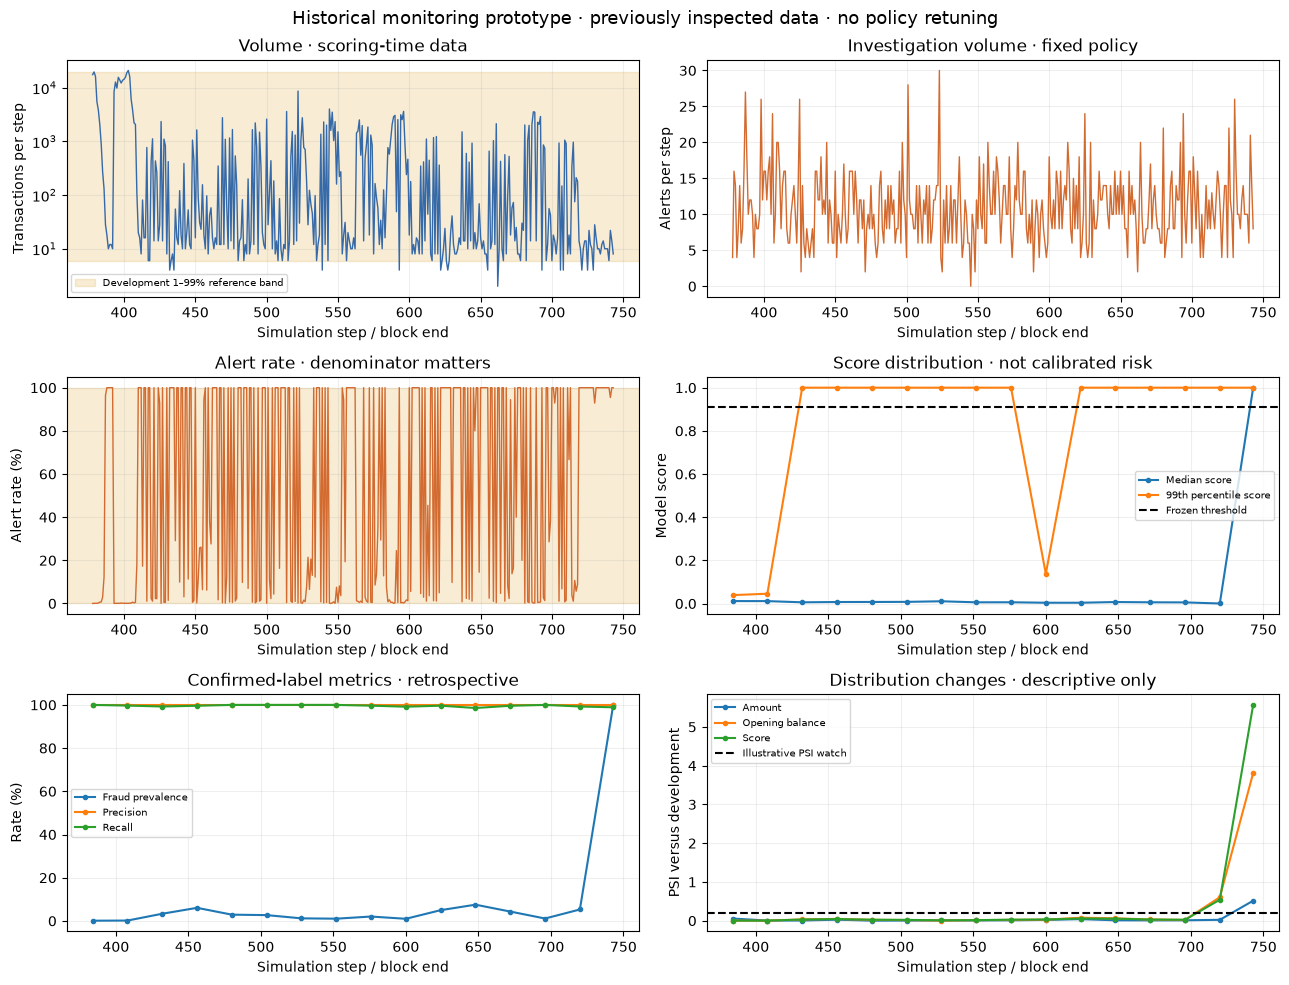

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10))
x = periods.last_step
axes[0, 0].plot(current_steps.index, current_steps.transactions, color='#3569a8', linewidth=1)
axes[0, 0].axhspan(bands['transactions']['low'], bands['transactions']['high'], color='#e5b455', alpha=0.25,
                   label='Development 1–99% reference band')
axes[0, 0].set(yscale='symlog', ylabel='Transactions per step', title='Volume · scoring-time data')
axes[0, 0].legend(fontsize=7)
axes[0, 1].plot(current_steps.index, current_steps.alerts, color='#d36b30', linewidth=1)
axes[0, 1].set(ylabel='Alerts per step', title='Investigation volume · fixed policy')
axes[1, 0].plot(current_steps.index, 100 * current_steps.alert_rate, color='#d36b30', linewidth=1)
axes[1, 0].axhspan(100 * bands['alert_rate']['low'], 100 * bands['alert_rate']['high'], color='#e5b455', alpha=0.25)
axes[1, 0].set(ylabel='Alert rate (%)', title='Alert rate · denominator matters')
axes[1, 1].plot(x, periods.median_score, label='Median score', marker='o', markersize=3)
axes[1, 1].plot(x, periods.p99_score, label='99th percentile score', marker='o', markersize=3)
axes[1, 1].axhline(threshold, linestyle='--', color='black', label='Frozen threshold')
axes[1, 1].set(ylabel='Model score', title='Score distribution · not calibrated risk')
axes[1, 1].legend(fontsize=7)
for column, label in [('fraud_prevalence', 'Fraud prevalence'), ('precision', 'Precision'), ('recall', 'Recall')]:
    axes[2, 0].plot(x, 100 * periods[column], label=label, marker='o', markersize=3)
axes[2, 0].set(ylabel='Rate (%)', title='Confirmed-label metrics · retrospective')
axes[2, 0].legend(fontsize=7)
for feature, label in [('amount', 'Amount'), ('oldbalanceOrg', 'Opening balance'), ('score', 'Score')]:
    axes[2, 1].plot(x, periods[feature + '_PSI'], marker='o', markersize=3, label=label)
axes[2, 1].axhline(PSI_WATCH, linestyle='--', color='black', label='Illustrative PSI watch')
axes[2, 1].set(ylabel='PSI versus development', title='Distribution changes · descriptive only')
axes[2, 1].legend(fontsize=7)
for ax in axes.flat:
    ax.set_xlabel('Simulation step / block end')
fig.suptitle('Historical monitoring prototype · previously inspected data · no policy retuning', fontsize=13)
fig.tight_layout()
save_figure(fig, 'monitoring_overview')
plt.show()

## Distribution changes

Compare the development reference with three fixed consecutive replay blocks (378–499, 500–621 and 622–743).
These blocks are descriptive slices, not new test splits. Numeric curves show empirical cumulative distributions at
1,001 quantiles, including all rows. Amount and opening-balance axes use `log10(1 + dataset currency units)`.
The type panel shows within-block transaction shares, so changes in sample sizes are not confused with changes in mix.

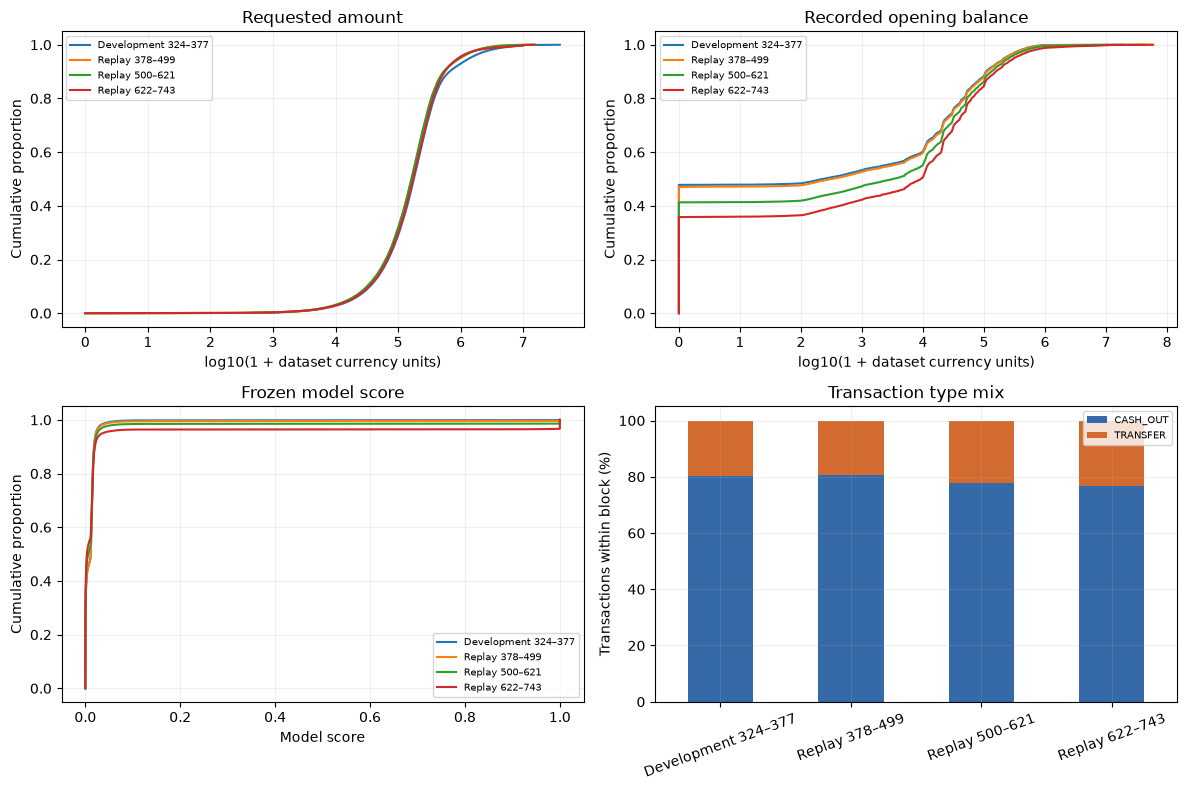

In [5]:
blocks = {'Development 324–377': reference,
          'Replay 378–499': current.loc[current.step.between(378, 499)],
          'Replay 500–621': current.loc[current.step.between(500, 621)],
          'Replay 622–743': current.loc[current.step.between(622, 743)]}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
quantiles = np.linspace(0, 1, 1001)
for ax, feature, title in [(axes[0, 0], 'amount', 'Requested amount'),
                           (axes[0, 1], 'oldbalanceOrg', 'Recorded opening balance'),
                           (axes[1, 0], 'score', 'Frozen model score')]:
    for label, group in blocks.items():
        values = group[feature].to_numpy()
        if feature != 'score': values = np.log10(1 + values)
        ax.plot(np.quantile(values, quantiles), quantiles, label=label)
    ax.set(title=title, ylabel='Cumulative proportion',
           xlabel='Model score' if feature == 'score' else 'log10(1 + dataset currency units)')
    ax.legend(fontsize=7)
type_shares = pd.DataFrame({name: group.type.value_counts(normalize=True) for name, group in blocks.items()}).T
(type_shares * 100).plot.bar(ax=axes[1, 1], stacked=True, color=['#3569a8', '#d36b30'])
axes[1, 1].set(ylabel='Transactions within block (%)', title='Transaction type mix', xlabel='')
axes[1, 1].tick_params(axis='x', rotation=20)
axes[1, 1].legend(fontsize=7)
fig.tight_layout()
save_figure(fig, 'monitoring_distributions')
plt.show()
save_table(type_shares.rename_axis('block').reset_index(), 'monitoring_type_shares')

## Performance by transaction type and missed fraud

Use the same fixed threshold for TRANSFER and CASH_OUT. Both aggregate and 24-step/type tables reuse the saved predictions.
Transaction amounts below describe labelled activity, not realised bank losses. No account names or row-level source
records are exported into the public report tables.

In [6]:
by_type_rows, by_type_time_rows = [], []
for transaction_type, group in current.groupby('type', observed=True):
    by_type_rows.append({'type': transaction_type, **metrics(group.isFraud, group.score, threshold)})
    grouped_periods = period_summary(group, threshold)
    grouped_periods.insert(0, 'type', transaction_type)
    by_type_time_rows.append(grouped_periods)
by_type = pd.DataFrame(by_type_rows)
by_type_time = pd.concat(by_type_time_rows, ignore_index=True)
missed = current.loc[current.isFraud.eq(1) & ~current.alert]
missed_summary = missed.groupby('type', observed=True).agg(
    missed_transactions=('row_id', 'size'), first_step=('step', 'min'), last_step=('step', 'max'),
    median_amount_dataset_currency_units=('amount', 'median'),
    total_transaction_value_dataset_currency_units=('amount', 'sum'),
    lowest_score=('score', 'min'), highest_score=('score', 'max'))
save_table(by_type, 'monitoring_by_type')
save_table(by_type_time, 'monitoring_by_type_time')
save_table(missed_summary.reset_index(), 'monitoring_missed_fraud')
display(by_type.round(6))
display(by_type_time[['type', 'first_step', 'last_step', 'transactions', 'fraud_count',
                      'fraud_prevalence', 'precision', 'recall', 'FP', 'FN', 'alerts']].round(5))
display(missed_summary.round(5))

,type,transactions,fraud_count,fraud_prevalence,precision,recall,F1,AP,threshold,alerts,alert_rate,TP,FP,FN,TN
0,CASH_OUT,324885,2005,0.006171,1.0,0.993516,0.996748,1.0,0.911739,1992,0.006131,1992,0,13,322880
1,TRANSFER,83192,2005,0.024101,1.0,0.997506,0.998752,1.0,0.911739,2000,0.024041,2000,0,5,81187


,type,first_step,last_step,transactions,fraud_count,fraud_prevalence,precision,recall,FP,FN,alerts
0,CASH_OUT,378,384,53515,33,0.00062,1.0,1.00000,0,0,33
1,CASH_OUT,385,408,152162,160,0.00105,1.0,0.99375,0,1,159
2,CASH_OUT,409,432,6201,134,0.02161,1.0,0.98507,0,2,132
3,CASH_OUT,433,456,3230,128,0.03963,1.0,1.00000,0,0,128
4,CASH_OUT,457,480,6191,118,0.01906,1.0,1.00000,0,0,118
5,CASH_OUT,481,504,7567,136,0.01797,1.0,1.00000,0,0,136
6,CASH_OUT,505,528,16732,128,0.00765,1.0,1.00000,0,0,128
7,CASH_OUT,529,552,16132,108,0.00669,1.0,1.00000,0,0,108
8,CASH_OUT,553,576,10676,140,0.01311,1.0,0.99286,0,1,139
9,CASH_OUT,577,600,19054,120,0.00630,1.0,0.99167,0,1,119


,missed_transactions,first_step,last_step,median_amount_dataset_currency_units,total_transaction_value_dataset_currency_units,lowest_score,highest_score
type,,,,,,,
CASH_OUT,13,387,741,0.0,0.00,0.29957,0.29957
TRANSFER,5,456,714,10000000.0,40399045.08,0.53854,0.91113


## Analyst interpretation and follow-up

| Indicator changes | Checks before drawing a risk conclusion |
|---|---|
| Volume falls or disappears | Check ingestion completeness, duplicate handling, type filters, missing steps and simulation/extract coverage. Reconcile with the upstream source. |
| Alert rate rises while alert count is steady | Inspect the denominator and legitimate volume; distinguish more fraud from fewer legitimate transactions. |
| Amount or type mix changes | Check activity composition and within-type distributions before attributing the change to fraud behaviour. |
| Opening-balance or score distribution shifts | Verify the balance snapshot and feature mapping, cancellation conventions and model version. Scores are not calibrated probabilities. |
| Precision falls or missed fraud rises | Check label maturity, adjudication changes and case definitions, then inspect confirmed false positives/negatives by type and time. |
| All-fraud or very small blocks | Investigate coverage and record counts; do not treat unstable rates or undefined AP as robust model evidence. |

Escalate a confirmed data-quality issue before changing the model. Any proposed policy revision requires development-only
validation and genuinely new future evidence. This prototype does not implement case management, automatic retraining,
customer intervention or real-time alert delivery.

The development reference can already contain very low-volume, high-alert-rate hours. Its upper percentile band may therefore be too broad to identify a material shift. Report that blind spot rather than tightening the band after inspecting the replay. Longer, seasonally matched development reference periods are needed before setting operational limits.

In [7]:
summary = {
    'historical_transactions': len(current), 'historical_alerts': reproduced_metrics['alerts'],
    'false_positives': reproduced_metrics['FP'], 'missed_fraud': reproduced_metrics['FN'],
    'volume_watch_steps': int(current_steps.transactions_outside_reference.sum()),
    'alert_rate_watch_steps': int(current_steps.alert_rate_outside_reference.sum()),
    'distribution_watch_periods': int(periods.distribution_watch.sum()),
    'type_mix_watch_periods': int(periods.type_mix_watch.sum()),
    'low_volume_periods': int(periods.low_volume.sum()), 'periods': len(periods),
    'reference_steps': len(reference_steps), 'replay_steps': len(current_steps),
}
(ROOT / 'reports' / 'monitoring_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
display(Markdown(
    f"This replay covers **{len(current):,} eligible transactions** and **{reproduced_metrics['alerts']:,} alerts**. "
    f"The reference bands flag **{summary['volume_watch_steps']} simulation steps** for volume and "
    f"**{summary['alert_rate_watch_steps']}** for alert rate; these are descriptive checks, not calibrated alarms. "
    f"There are **{summary['distribution_watch_periods']} of {len(periods)} blocks** above at least one illustrative PSI level. "
    f"Retrospective labels identify **{reproduced_metrics['FN']} missed fraud transactions** and "
    f"**{reproduced_metrics['FP']} false alerts**. The class-coverage audit in Notebook 02 shows why rising late "
    "fraud/alert percentages must be interpreted alongside legitimate transaction volume."
))

zero_amount_misses = int(missed.amount.eq(0).sum())
display(Markdown(
    f"**Missed-fraud audit:** {zero_amount_misses} of the {len(missed)} missed labelled transactions have a "
    "recorded amount of zero. Check their simulation and label semantics before interpreting them as financial exposure. "
    "The type-level table gives counts and transaction values; no threshold has been changed in response. "
    f"**Reference-band limitation:** the development 99th-percentile per-step alert rate is "
    f"{bands['alert_rate']['high']:.1%}. A wide band can miss important changes in the period-level distribution; "
    "the watch counts should not be presented as evidence that unflagged periods are stable."
))


This replay covers **408,077 eligible transactions** and **3,992 alerts**. The reference bands flag **15 simulation steps** for volume and **1** for alert rate; these are descriptive checks, not calibrated alarms. There are **2 of 16 blocks** above at least one illustrative PSI level. Retrospective labels identify **18 missed fraud transactions** and **0 false alerts**. The class-coverage audit in Notebook 02 shows why rising late fraud/alert percentages must be interpreted alongside legitimate transaction volume.

**Missed-fraud audit:** 13 of the 18 missed labelled transactions have a recorded amount of zero. Check their simulation and label semantics before interpreting them as financial exposure. The type-level table gives counts and transaction values; no threshold has been changed in response. **Reference-band limitation:** the development 99th-percentile per-step alert rate is 100.0%. A wide band can miss important changes in the period-level distribution; the watch counts should not be presented as evidence that unflagged periods are stable.

## Limitations and next steps

This is a historical prototype using an already-inspected synthetic dataset and a balance-dependent policy with unverified
as-of provenance. It has no real-time feed, confirmation timestamps, case deduplication, staffing model or intervention
outcomes. The short development reference does not establish seasonality or a reliable false-alarm rate. Thresholds are
fixed descriptive bands or labelled demonstrations, not regulatory limits. Distribution shifts are not causal findings.

A next iteration should use verified data contracts, label-maturity cohorts, longer seasonally matched reference periods,
case-level outcomes and analyst-agreed investigation capacity. Validate monitoring rules against independent future data
before treating them as operational controls. Do not describe flagged transaction value as money saved.